# Bayesian Deep Learning

Bayesian Deep Learning is a field that tries to quantify uncertainty in artificial neural networks. In this approach, the weights of a model are treated as distributions instead of fixed values.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import torch
from torch.nn import GaussianNLLLoss
from torch.optim import Adam

from pai import BNNLA, BNNVI, BNNMCMC, BNNDropout, DeepEnsemble
from scoring import bnn_loss, negative_elbo, sgdl_loss

mpl.rc_file_defaults()

## Toy Data

In [2]:
rng = np.random.default_rng(42)

x_numpy = np.linspace(-6 * np.pi, 6 * np.pi, 1000).reshape((1000, 1))
x_short = np.concatenate([x_numpy[:20], x_numpy[40:80], x_numpy[100:120], x_numpy[150:]])
y_numpy = np.sin(0.2 * x_short) + rng.normal(0, 0.2, size=x_short.shape)

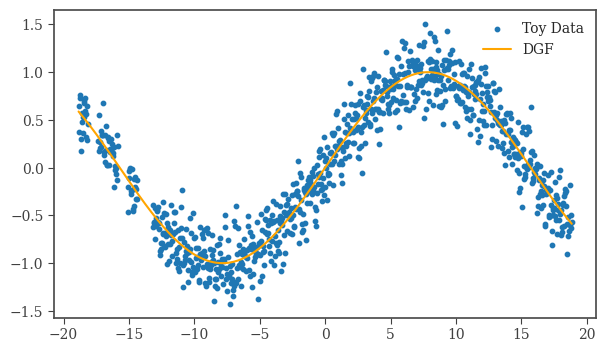

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(x_short, y_numpy, label="Toy Data", s=10)
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.legend()

plt.show()

## BNN with Laplace Approximation

A common problem with such Bayesian methods are intractable computations due to high computation costs. As such, it is common to use approximations. One possible approach are neural networks with Laplace Approximations, where the true posterior is approximated using a Gaussian distribution.

In [4]:
x = torch.from_numpy(x_short).to(torch.float32)
y = torch.from_numpy(y_numpy).to(torch.float32)

In [5]:
inv_prior = 0.009

bnn = BNNLA(x.shape[1], inv_prior)
optimizer = Adam(bnn.parameters(), lr=0.01, weight_decay=inv_prior)

for epoch in range(2_000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn(x)
    loss = bnn_loss(y_mean, y_log_var, y)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 0.3562
E100: Loss -1.0273
E200: Loss -1.1185
E300: Loss -1.1100
E400: Loss -1.0856
E500: Loss -1.0953
E600: Loss -1.0159
E700: Loss -1.1274
E800: Loss -1.1292
E900: Loss -1.1280
E1000: Loss -1.1258
E1100: Loss -1.1032
E1200: Loss -1.0806
E1300: Loss -1.1307
E1400: Loss -1.1290
E1500: Loss -1.0896
E1600: Loss -1.1308
E1700: Loss -1.1277
E1800: Loss -1.1226
E1900: Loss -1.1280


In [6]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

bnn.covariance(x_long)
y_pred, var_pred, total_var_pred = bnn.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

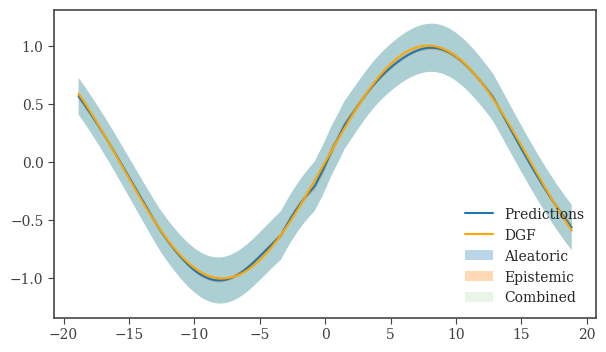

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, label="Aleatoric", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - epistemic_std, y_pred + epistemic_std, label="Epistemic", alpha=0.3)
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, label="Combined", alpha=0.1)

ax.legend()

plt.show()

## Bayesian Neural Network with Variational Inference

A Bayesian Neural Network treats parameters as distributions instead of weights. The implementation used here stores the mean and variance of a normal distribution for each weight. Since full computation of the posterior is impossible, the implementation furthermore uses variational inference, where the posterior is approximated using a simpler distribution. Furthermore, since this relies on differentiating with respect to the parameters we sample from, the reparametrization trick is used.

In [8]:
bnn_vi = BNNVI(x.shape[1])
optimizer = Adam(bnn_vi.parameters(), lr=0.01)

for epoch in range(1000):
    optimizer.zero_grad()

    y_mean, y_log_var = bnn_vi(x)

    loss = negative_elbo(y_mean, y_log_var, y, bnn_vi.kl_divergence())
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0:
        print(f"E{epoch}: Loss {loss.item():.4f}")

E0: Loss 3.4237
E100: Loss 2.7084
E200: Loss 2.5628
E300: Loss 2.5164
E400: Loss 2.4780
E500: Loss 2.4188
E600: Loss 2.4599
E700: Loss 2.3977
E800: Loss 2.5059
E900: Loss 2.4438


In the inference step, several weights are sample using Monte Carlo sampling. From these samples, the mean, epistemic and aleatoric variances are predicted.

In [9]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_vi.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

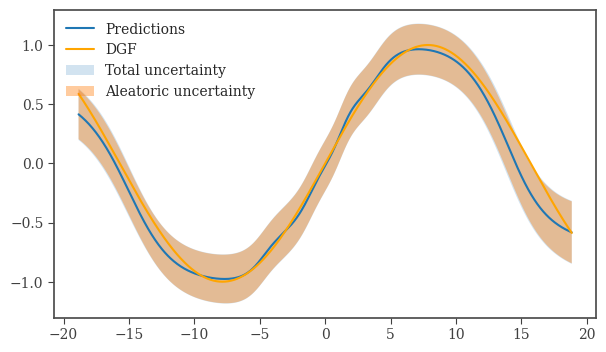

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty", )

ax.legend()

plt.show()

## MCMC for Neural Networks

There also exist MCMC methods for Bayesian Neural Networks. They work by saving weight samples every few training steps and averaging over model predictions of each stored weight sample to provide an estimate of the mean prediction. At the same time, this approach also gives an estimate of the epistemic uncertainty. The model used below is configured to predict the aleatoric uncertainty, too.

During training, random Gaussian noise is added. This is called Stochastic Gradient Langevin Dynamics.

In [11]:
num_samples, num_features = x.shape[0], x.shape[1]
random_permutation = torch.randperm(num_samples)

x = x[random_permutation]
y = y[random_permutation]

prior_variance = 1.0
bnn_mcmc = BNNMCMC(in_features=num_features, prior_variance=prior_variance)

batch_size = 64
steps = num_samples // batch_size
step_size = 2e-5
epochs = 500
burn_in_epochs = 450

for epoch in range(epochs):
    epoch_loss = 0
    for step in range(steps):
        x_batch = x[(step * batch_size):((step + 1) * batch_size)]
        y_batch = y[(step * batch_size):((step + 1) * batch_size)]
        bnn_mcmc.zero_grad()

        y_mean, y_log_var = bnn_mcmc(x_batch)

        nl_prior = bnn_mcmc.negative_log_prior()
        loss = sgdl_loss(y_mean, y_log_var, y_batch, nl_prior, num_samples)

        loss.backward()
        with torch.no_grad():
            for parameter in bnn_mcmc.parameters():
                noise = torch.randn_like(parameter)

                parameter.add_(
                    -0.5 * step_size * parameter.grad + step_size ** 0.5 * noise
                )
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"E{epoch}: Loss {epoch_loss / steps}")

    if epoch > burn_in_epochs:
        bnn_mcmc.store_weight_sample()

E0: Loss 349.1563524518694
E10: Loss 24.622065476008824
E20: Loss -182.19381727491105
E30: Loss -199.25313227517265
E40: Loss -201.06900215148926
E50: Loss -207.31255286080497
E60: Loss -225.89245523725236
E70: Loss -218.89124516078405
E80: Loss -230.50799233572823
E90: Loss -236.0833980015346
E100: Loss -259.8855100359236
E110: Loss -282.99255916050504
E120: Loss -311.24137333461215
E130: Loss -326.8110874720982
E140: Loss -364.3599548339844
E150: Loss -380.5652847290039
E160: Loss -433.66043962751115
E170: Loss -462.5553305489676
E180: Loss -488.79238673618863
E190: Loss -516.7805502755301
E200: Loss -534.5625937325614
E210: Loss -565.2507847377232
E220: Loss -580.5729217529297
E230: Loss -607.2078159877232
E240: Loss -630.9010925292969
E250: Loss -660.5752519880023
E260: Loss -550.9200657435825
E270: Loss -643.5513632638114
E280: Loss -595.500970023019
E290: Loss -638.2564261300223
E300: Loss -708.3327069963727
E310: Loss -696.8649248395648
E320: Loss -633.110347202846
E330: Loss -6

In [12]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_mcmc.predict(x_long)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

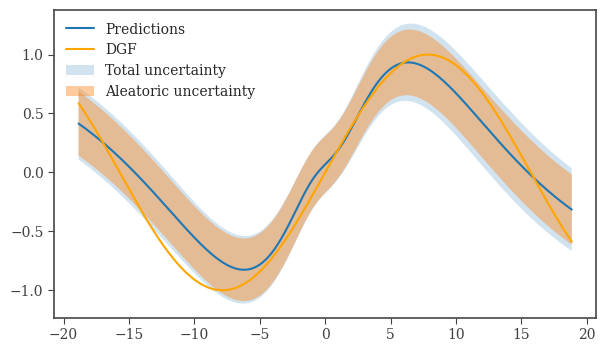

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4, label="Aleatoric uncertainty")

ax.legend()

plt.show()

## BNN with Dropout as Variational Inference

Using dropout during inference can be seen as a way of performing variational inference. The input is sent through the model multiple times with inference kept on, and these estimates are used to approximate the epistemic uncertainty and mean prediction. The model is configured to predict the aleatoric uncertainty, too.

In [14]:
num_samples, num_features = x.shape[0], x.shape[1]
random_permutation = torch.randperm(num_samples)

x = x[random_permutation]
y = y[random_permutation]

bnn_dropout = BNNDropout(in_features=num_features)
optimizer = Adam(bnn_dropout.parameters(), lr=0.002)
nll_loss = GaussianNLLLoss()

batch_size = 64
steps = num_samples // batch_size
step_size = 2e-5
epochs = 500

for epoch in range(epochs):
    epoch_loss = 0
    for step in range(steps):
        x_batch = x[(step * batch_size):((step + 1) * batch_size)]
        y_batch = y[(step * batch_size):((step + 1) * batch_size)]
        optimizer.zero_grad()

        y_mean, y_log_var = bnn_dropout(x_batch)
        y_var = y_log_var.exp()

        loss = nll_loss(y_mean, y_batch, y_var)
        loss.backward()

        optimizer.step()
        epoch_loss += loss.item()
    if epoch % 10 == 0:
        print(f"E{epoch}: Loss {epoch_loss / steps}")

E0: Loss 6.529793845755713
E10: Loss 0.39180402351277216
E20: Loss 0.16036683320999146
E30: Loss -0.028959399155740227
E40: Loss -0.15516374419842446
E50: Loss -0.213229167674269
E60: Loss -0.2708851471543312
E70: Loss -0.27954815993351595
E80: Loss -0.30461668968200684
E90: Loss -0.3439302625400679
E100: Loss -0.36456185792173657
E110: Loss -0.35039731221539633
E120: Loss -0.311524683875697
E130: Loss -0.31296821417553083
E140: Loss -0.3654079394681113
E150: Loss -0.4152305998972484
E160: Loss -0.37835815974644255
E170: Loss -0.4126690136534827
E180: Loss -0.3696438989468983
E190: Loss -0.43275169123496326
E200: Loss -0.4623900183609554
E210: Loss -0.44247731140681673
E220: Loss -0.4766758361033031
E230: Loss -0.45643529295921326
E240: Loss -0.4481427712099893
E250: Loss -0.48237283527851105
E260: Loss -0.49542728066444397
E270: Loss -0.5015856836523328
E280: Loss -0.5327266390834536
E290: Loss -0.5016876480409077
E300: Loss -0.5493143669196537
E310: Loss -0.5131515775408063
E320: Los

In [15]:
x_long = torch.from_numpy(x_numpy).to(torch.float32)

y_pred, var_pred, total_var_pred = bnn_dropout.predict(x_long, num_passes=300)

y_pred = y_pred.detach().numpy().ravel()
var_pred = var_pred.detach().numpy().ravel()

total_var = total_var_pred.detach().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

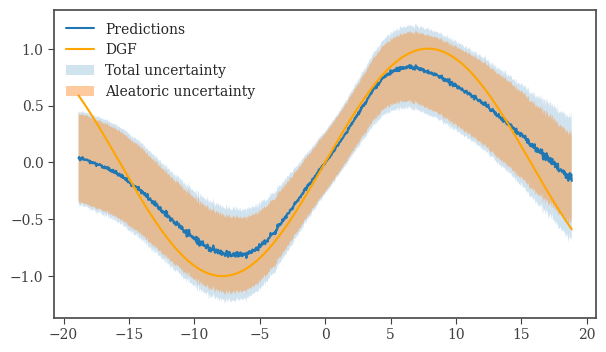

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4,
                label="Aleatoric uncertainty")

ax.legend()

plt.show()

## Probabilistic Ensembles

Probabilistic Ensembles or Deep Ensembles are a collection of neural networks, where each network is trained separately on random subsets of the data. During inference, the output of each model is aggregated to provide an estimate of the mean and variance.

In [19]:
num_samples, num_features = x.shape[0], x.shape[1]

device = "cuda" if torch.cuda.is_available() else "cpu"

deep_ensemble = DeepEnsemble(in_features=num_features)
deep_ensemble = deep_ensemble.to(device)

batch_size = 64
step_size = 2e-5
epochs = 500

for model in deep_ensemble.models:
    optimizer = Adam(model.parameters(), lr=0.002)
    nll_loss = GaussianNLLLoss()

    # Draw random subset
    random_permutation = torch.randperm(int(num_samples * 0.7))
    x_subset = x[random_permutation].to(device)
    y_subset = y[random_permutation].to(device)

    steps = x_subset.shape[0] // batch_size
    for epoch in range(epochs):
        epoch_loss = 0
        for step in range(steps):
            x_batch = x_subset[(step * batch_size):((step + 1) * batch_size)]
            y_batch = y_subset[(step * batch_size):((step + 1) * batch_size)]
            optimizer.zero_grad()

            y_mean, y_log_var = model(x_batch)
            y_var = y_log_var.exp()

            loss = nll_loss(y_mean, y_batch, y_var)
            loss.backward()

            optimizer.step()
            epoch_loss += loss.item()
        if epoch % 100 == 0:
            print(f"E{epoch}: Loss {epoch_loss / steps}")

E0: Loss 0.15619690120220184
E100: Loss -1.0518652379512787
E200: Loss -1.0846709430217742
E300: Loss -1.0964708149433136
E400: Loss -1.1039230048656463
E0: Loss 0.23304965831339358
E100: Loss -1.0919085621833802
E200: Loss -1.1183915972709655
E300: Loss -1.0911820650100708
E400: Loss -1.1135251641273498
E0: Loss 0.17568561304360628
E100: Loss -1.1114731431007385
E200: Loss -1.1059059262275697
E300: Loss -1.1120244264602661
E400: Loss -1.1186795115470887
E0: Loss 0.13172439225018023
E100: Loss -1.0658476650714874
E200: Loss -1.0821276128292083
E300: Loss -1.0929131150245666
E400: Loss -1.0992433905601502
E0: Loss 0.1931130677461624
E100: Loss -1.089663064479828
E200: Loss -1.1068570256233214
E300: Loss -1.1126806139945984
E400: Loss -1.1158073902130128
E0: Loss 2.204475399851799
E100: Loss -1.1103490471839905
E200: Loss -1.1155368566513062
E300: Loss -1.117898201942444
E400: Loss -1.1194854617118835
E0: Loss 0.1806485563516617
E100: Loss -1.1264859437942505
E200: Loss -1.12606620788574

In [22]:
x_long = torch.from_numpy(x_numpy).to(dtype=torch.float32, device=device)

y_pred, var_pred, total_var_pred = deep_ensemble.predict(x_long)

y_pred = y_pred.detach().cpu().numpy().ravel()
var_pred = var_pred.detach().cpu().numpy().ravel()

total_var = total_var_pred.detach().cpu().numpy().ravel()

epistemic_var = total_var - var_pred
epistemic_std = epistemic_var ** 0.5

aleatoric_std = var_pred ** 0.5

total_std = total_var ** 0.5

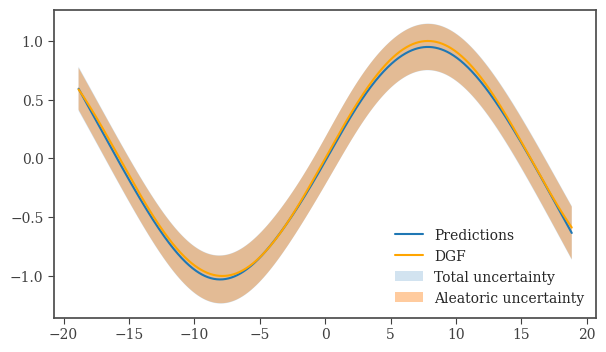

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(x_numpy, y_pred, label="Predictions")
ax.plot(x_numpy, np.sin(0.2 * x_numpy), label="DGF", color="orange")
ax.fill_between(x_numpy.ravel(), y_pred - total_std, y_pred + total_std, alpha=0.2, label="Total uncertainty", )
ax.fill_between(x_numpy.ravel(), y_pred - aleatoric_std, y_pred + aleatoric_std, alpha=0.4,
                label="Aleatoric uncertainty")

ax.legend()

plt.show()